In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\datasets\Diwali Sales Data.csv", encoding="latin-1")

In [3]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
df.shape

(11251, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
# drop status & unnamed1 column
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [7]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
# drop null values
df.dropna(inplace=True)

In [9]:
# change datatype of Amount
df['Amount'] = df['Amount'].astype('int')

In [10]:
# description of data
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

### EDA

In [12]:
import warnings
warnings.filterwarnings('ignore')

#### Gender

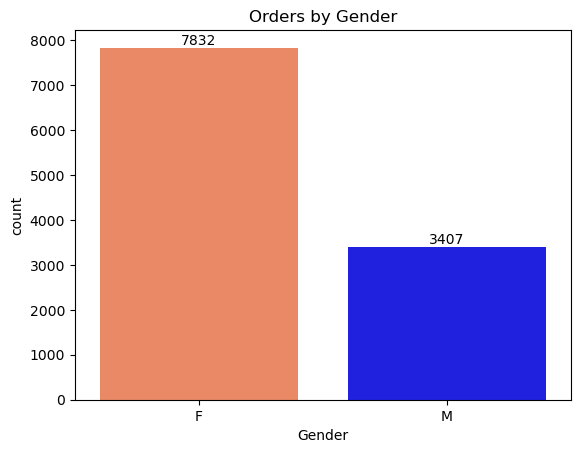

In [31]:
ax = sns.countplot(x = 'Gender', data=df, palette=['coral','blue'])
plt.title("Orders by Gender")

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

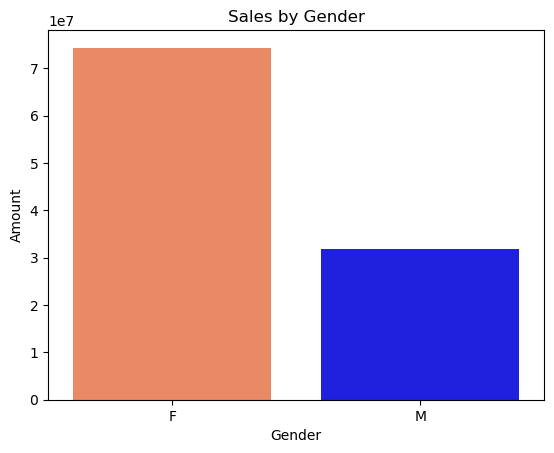

In [35]:
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False)

sns.barplot(x = 'Gender', y = 'Amount', data=sales_gen, palette=['coral','blue'])
plt.title("Sales by Gender")
plt.show()

- From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than males.

### Age

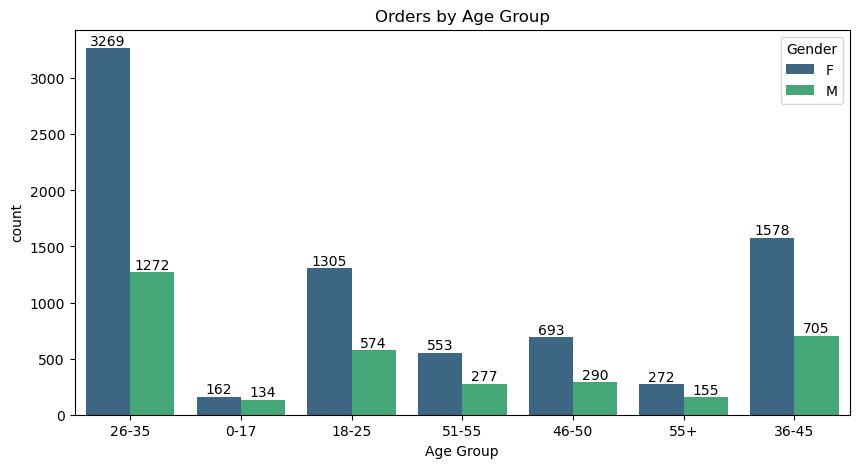

In [15]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x = 'Age Group', data=df, hue='Gender', palette='viridis')
plt.title("Orders by Age Group")

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

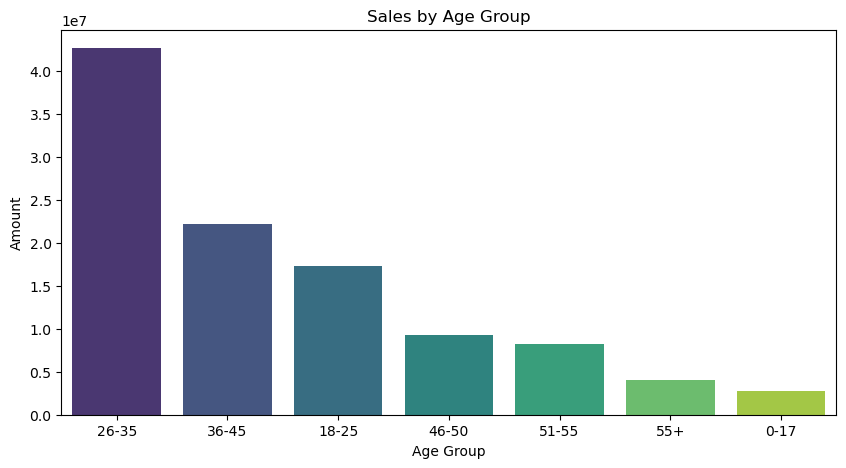

In [16]:
plt.figure(figsize=(10,5))
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False)

sns.barplot(x = 'Age Group', y = 'Amount', data=sales_age, palette='viridis')
plt.title("Sales by Age Group")
plt.show()

- from above graphs we can see that most of the buyers are of age group between 26-35 yrs female.

### State

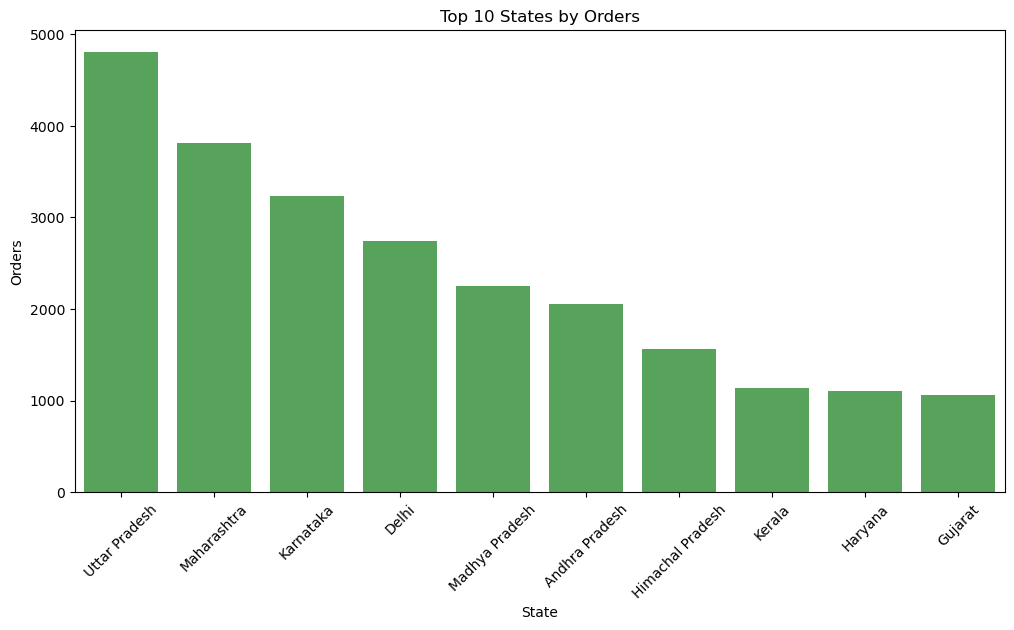

In [17]:
plt.figure(figsize=(12,6))
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by ='Orders', ascending=False).head(10)

sns.barplot(x = 'State', y = 'Orders', data=sales_state, palette=['#4CAF50'])
plt.xticks(rotation=45)
plt.title("Top 10 States by Orders")
plt.show()

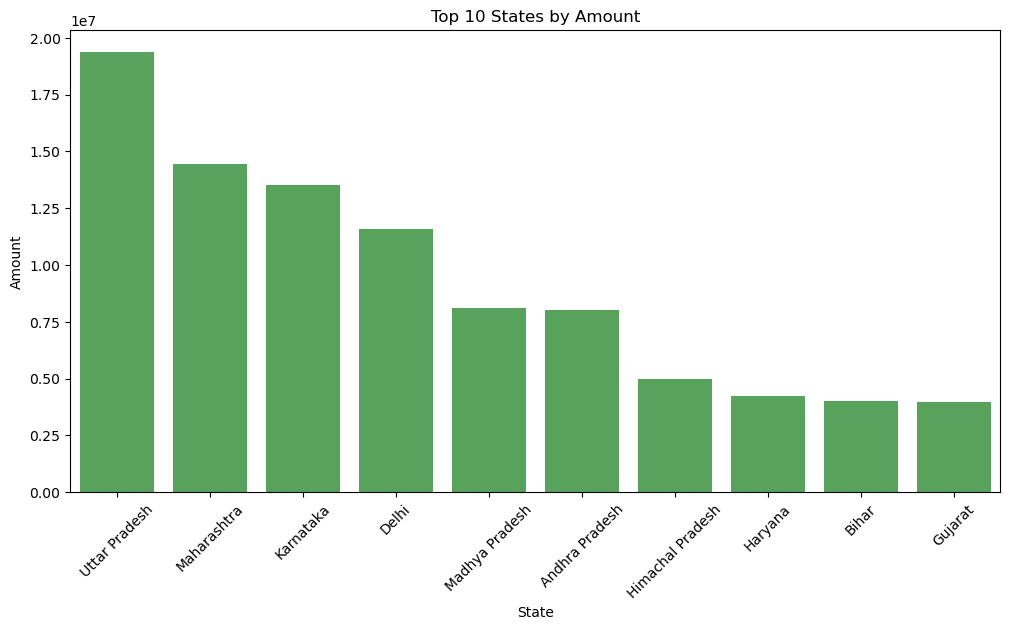

In [18]:
plt.figure(figsize=(12,6))
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False).head(10)

sns.barplot(x = 'State', y = 'Amount', data=sales_state, palette=['#4CAF50'])
plt.xticks(rotation=45)
plt.title("Top 10 States by Amount")
plt.show()

- we can see that most of the orders and total sales are from Uttar Pradesh, Maharastra, Karnataka respectively.

### Zone

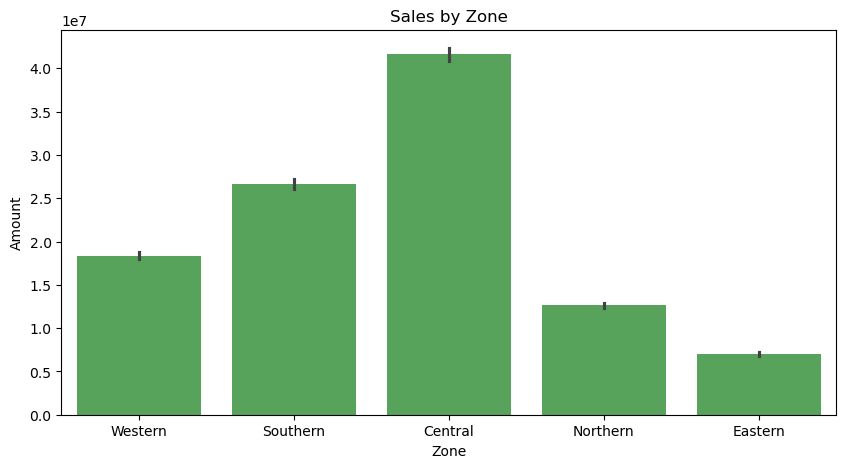

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x='Zone', y='Amount', data=df, estimator=sum, palette=['#4CAF50'])
plt.title("Sales by Zone")
plt.show()

- most of the sales are from Central Zone

### Marital Status

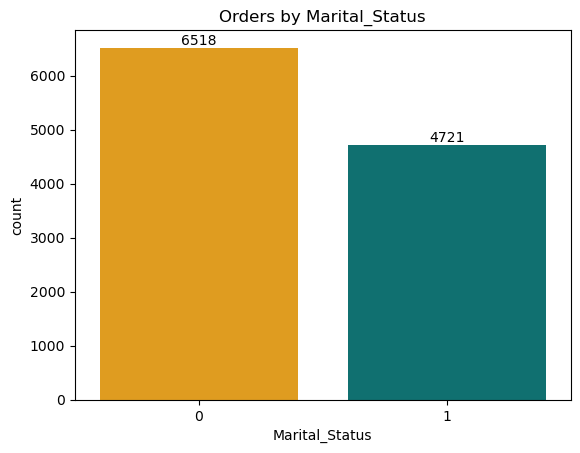

In [28]:

ax = sns.countplot(x = 'Marital_Status', data=df, palette=['orange', 'Teal'])
plt.title("Orders by Marital_Status")

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

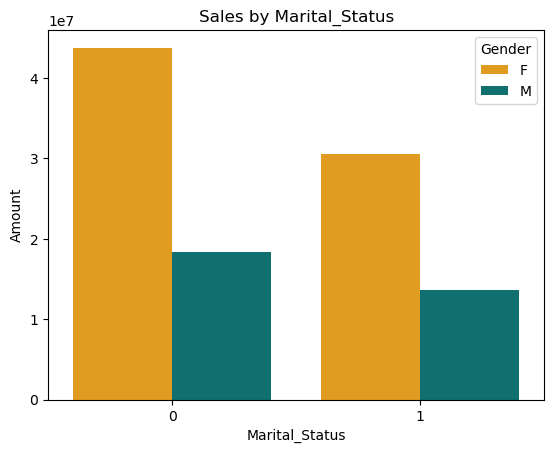

In [27]:

sales_ms = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False)

sns.barplot(x = 'Marital_Status', y = 'Amount', data = sales_ms, hue='Gender', palette=['orange', 'Teal'])
plt.title("Sales by Marital_Status")
plt.show()

- From above graphs we can see that most of the buyers are married womens and they have high purchasing power

### Occupation

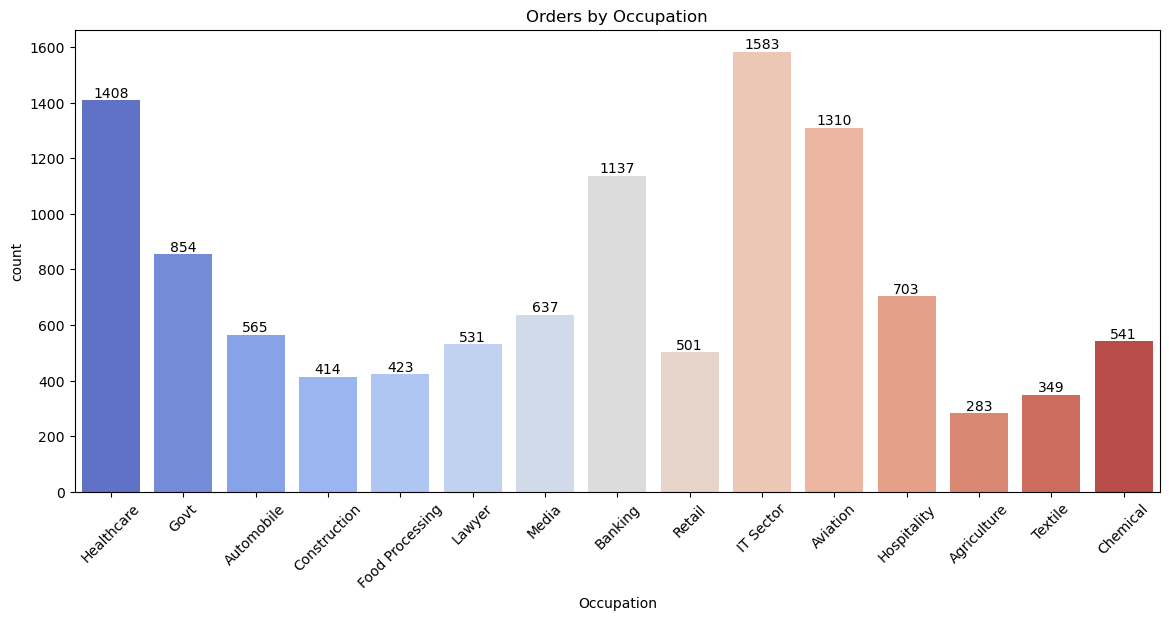

In [25]:
plt.figure(figsize=(14,6))
ax = sns.countplot(x = 'Occupation', data=df, palette='coolwarm')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Orders by Occupation")
plt.xticks(rotation=45)
plt.show()

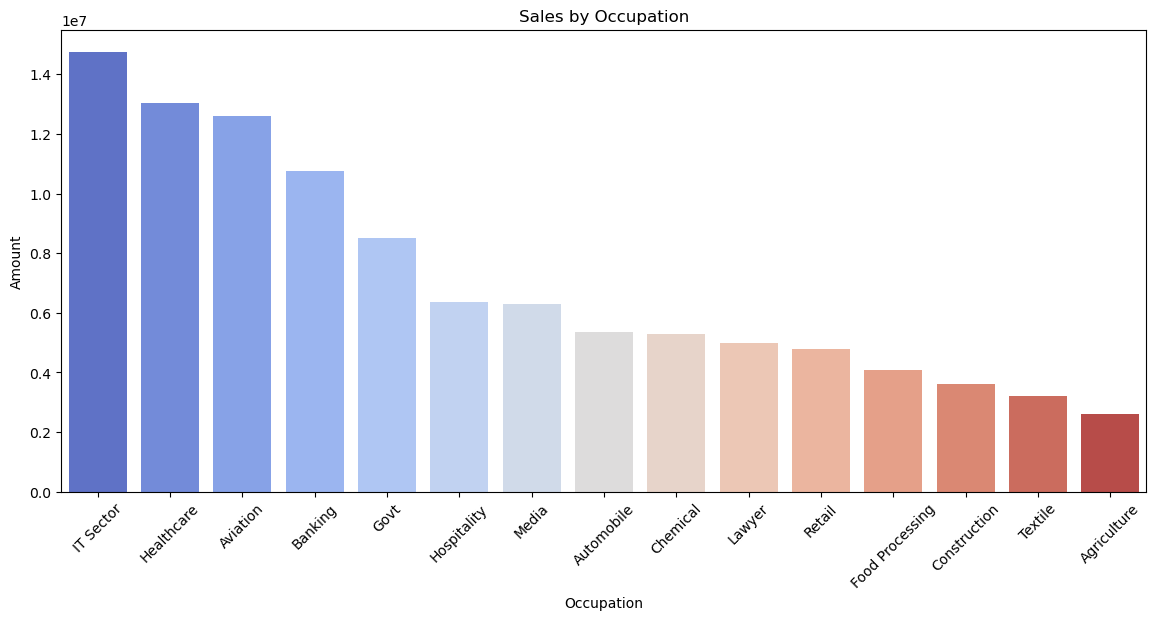

In [30]:
plt.figure(figsize=(14,6))
sales_occ = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False)

sns.barplot(x = 'Occupation', y = 'Amount', data = sales_occ, palette='coolwarm')
plt.title("Sales by Occupation")
plt.xticks(rotation=45)
plt.show()

- From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sectors.

### Product Category

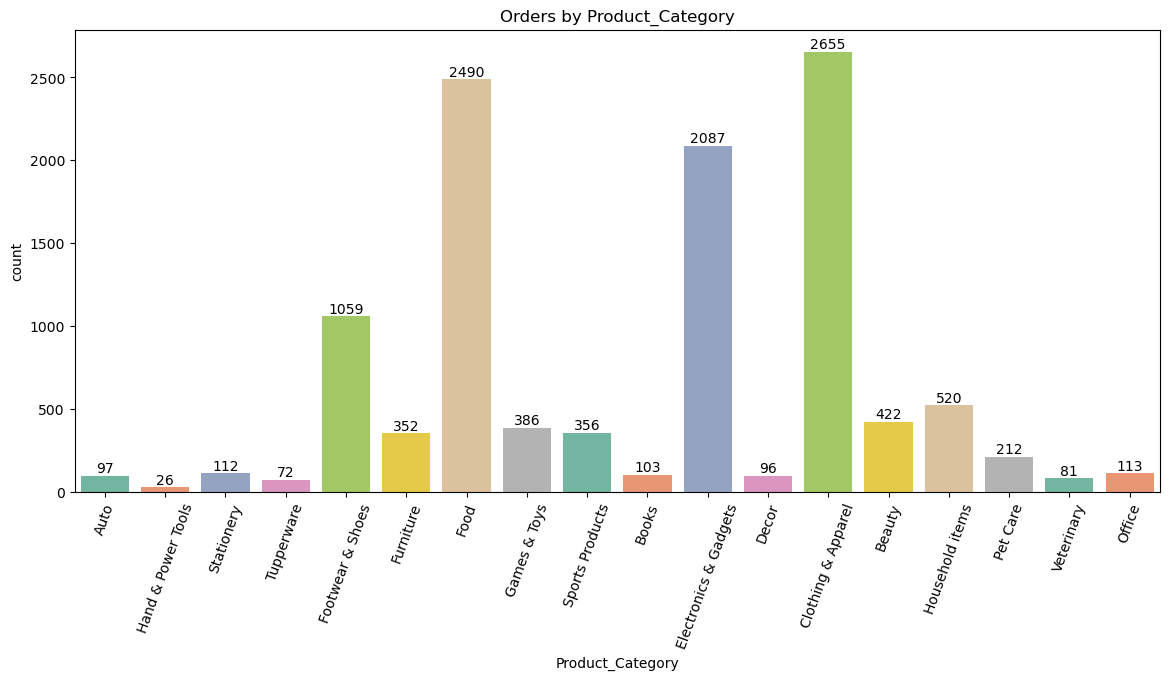

In [39]:
plt.figure(figsize=(14,6))
ax = sns.countplot(x = 'Product_Category', data=df, palette='Set2')

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Orders by Product_Category")
plt.xticks(rotation=70)
plt.show()

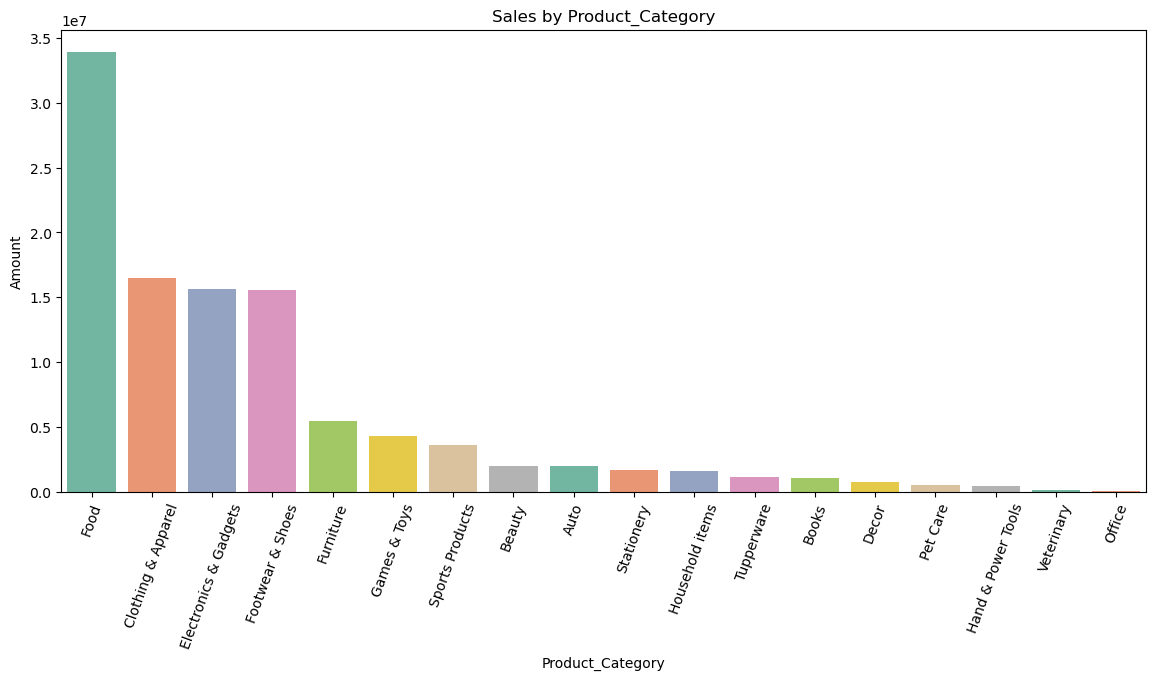

In [40]:
plt.figure(figsize=(14,6))
sales_prod = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False)

sns.barplot(x = 'Product_Category', y = 'Amount', data = sales_prod, palette='Set2')
plt.title("Sales by Product_Category")
plt.xticks(rotation=70)
plt.show()

- From above graphs we can see that most of the sold products are from food, clothing, and electronics

### Product ID

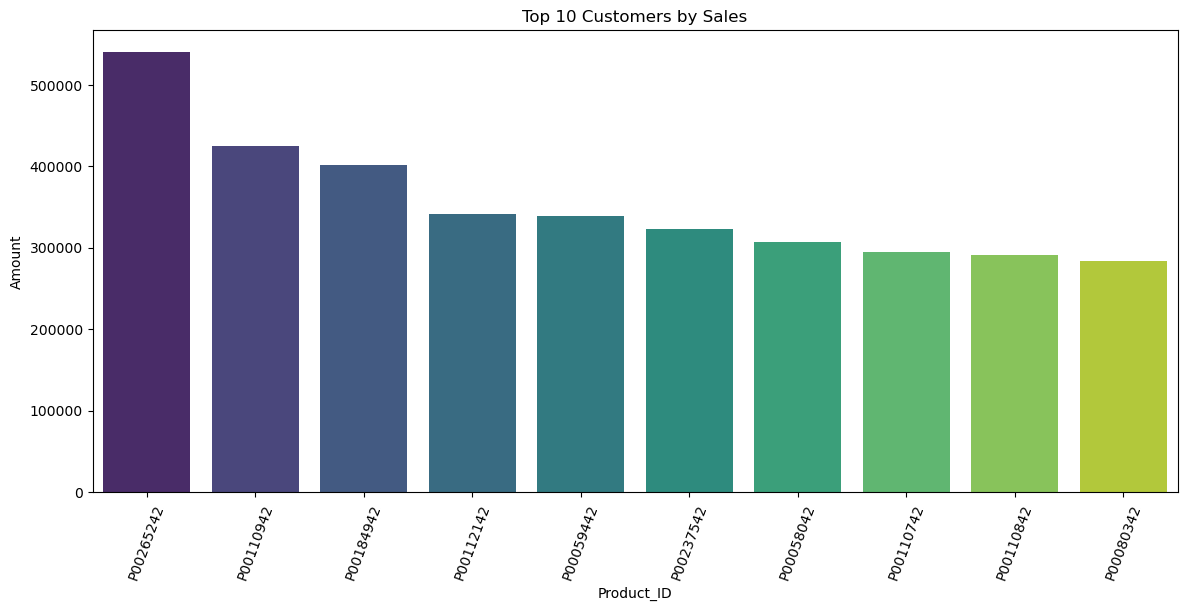

In [51]:
plt.figure(figsize=(14,6))
sales_id = df.groupby(['Product_ID'], as_index=False)['Amount'].sum().sort_values(by ='Amount', ascending=False).head(10)

sns.barplot(x = 'Product_ID', y = 'Amount', data = sales_id, palette='viridis')
plt.title("Top 10 Customers by Sales")
plt.xticks(rotation=70)
plt.show()

### Heatmap

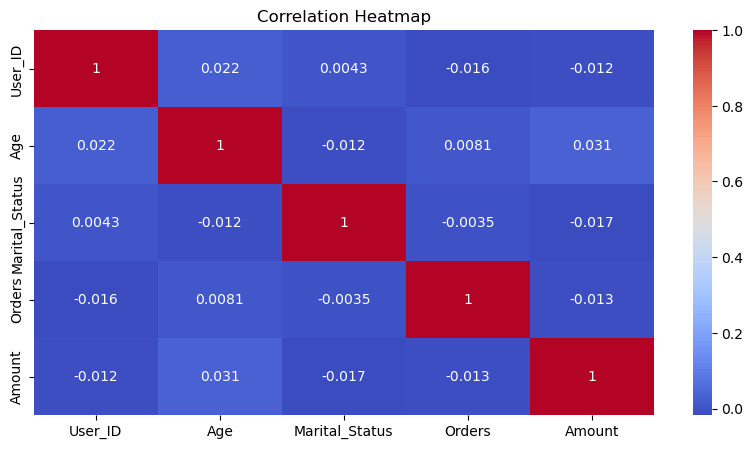

In [44]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- shows the ralationship between Users, Age, Orders, Amount, Marital_Status.

### Sales Overview

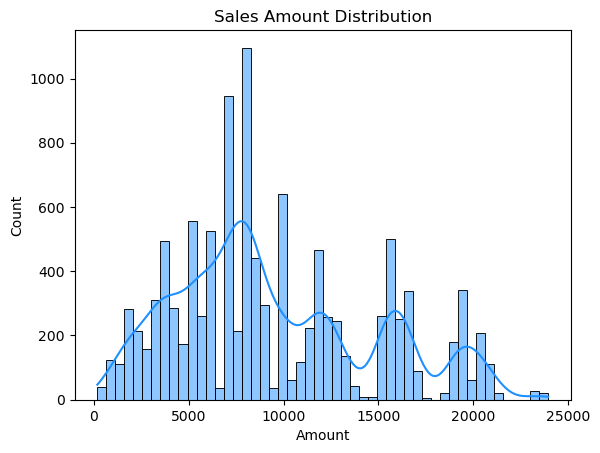

In [53]:
sns.histplot(df['Amount'], bins=50, kde=True, color='#1E90FF')
plt.title("Sales Amount Distribution")
plt.show()

- Most of the people spend medium amount during Diwali Shooping 5000-10000. Some people spends much higher amounts which boost overall sales significantly.

## Conclusion

- Married women age group 26-35 years from UP, Maharshtra and Karnataka.
- Most of the people working in IT, Healthcare, Aviation sectors, they are likely buy products from food, Clothing, and Electonics Category.
- Most of the people spend medium amount ( 5000-10000 )during Diwali Shopping.